# 숙제 3

데이터과학 입문

원중호 (서울대학교 통계학과)  
June 2026

## 지시사항

제출마감 2026-06-15 23:00

1.  R과 Python을 모두 사용하여 사용된 코드와 데이터랭글링 절차,
    분석결과를 설명한다. 두 언어의 분석결과가 차이가 있으면 그 이유를
    설명한다.
2.  [Quarto
    Markdown](https://quarto.org/docs/authoring/markdown-basics.html)을
    사용한다. 제공된 숙제 `.qmd` 파일에 본인의 답안을 “답안” 절에
    추가하여 제출한다. Quarto Markdown은 RStudio 또는 Visual Studio
    Code에 [Quarto
    Extension](https://marketplace.visualstudio.com/items?itemName=quarto.quarto)을
    추가하여 컴파일, 다른 문서 형식으로 변환할 수 있다.
3.  R의 `reticulate` 패키지를 사용하면 하나의 `.qmd` 파일 안에서 R과
    Python을 동시에 사용할 수 있다. 이때 다음 문법을 사용하여 두 언어
    코드를 탭으로 구분한다. 숙제 `.qmd` 파일은 `reticulate`을 사용하도록
    준비되어 있다.

```` markdown
::: {.panel-tabset}

## R

```{r}
R code
```

## Python

```{python}
Python code
```

:::
````

1.  `.qmd`를 컴파일하여 생성된 `.html` 파일을 함께 저장소에 제출한다.
2.  함께 제공된 `student.yml`을 함께 작성하여 저장소에 제출한다.

## 평가 기준

1.  재현성: 제출된 저장소의 `.qmd` 파일을 컴파일하여 함께 제출된 `.html`
    파일과 동일한 결과가 나와야 한다.
2.  분석의 정확성: 분석은 올바른 기술적 세부 사항을 포함하여 수행되어야
    한다.
3.  보고서의 전반적인 품질: 데이터 가공 및 분석 결과가 명확하고 자세하게
    설명되어야 한다.
4.  코드의 전반적인 품질: 코드는 체계적으로 정리되어 있어야 하며,
    가독성을 높이기 위해 적절한 주석이 포함되어야 한다.

#### **늦게 제출된 과제물은 받지 않는다.**

다음의 패키지가 필요하다.

## R

``` r
library(ggplot2)
library(dplyr)
library(Lahman)
library(forcats)
library(tidyverse)
library(mosaicData)
library(lubridate)
library(scales)
library(googlesheets4)
library(rvest)
library(purrr)
library(NHANES)
library(patchwork)
```

## Python

``` python
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import t
import polars as pl
import pylahman
import statsmodels.api as sm
from scipy.stats import chi2
from plotnine import *
import statsmodels.formula.api as smf
from scipy.special import gammaln
```

# 1부 교과서 연습문제

## 문제 1-1

1.  MDSR 10장 연습문제 10.6.6

### 답안

## R

``` r
smoking <- NHANES %>%
  filter(Age >= 20) %>%
  mutate(
    CurrentSmoker = case_when(
      Smoke100 == "No" ~ "No",
      Smoke100 == "Yes" ~ as.character(SmokeNow),
      TRUE ~ NA_character_
    ),
    CurrentSmoker = factor(CurrentSmoker, levels = c("No", "Yes"))
  )
smoking
```

    # A tibble: 7,235 × 77
          ID SurveyYr Gender   Age AgeDecade AgeMonths Race1 Race3 Education     
       <int> <fct>    <fct>  <int> <fct>         <int> <fct> <fct> <fct>         
     1 51624 2009_10  male      34 " 30-39"        409 White <NA>  High School   
     2 51624 2009_10  male      34 " 30-39"        409 White <NA>  High School   
     3 51624 2009_10  male      34 " 30-39"        409 White <NA>  High School   
     4 51630 2009_10  female    49 " 40-49"        596 White <NA>  Some College  
     5 51647 2009_10  female    45 " 40-49"        541 White <NA>  College Grad  
     6 51647 2009_10  female    45 " 40-49"        541 White <NA>  College Grad  
     7 51647 2009_10  female    45 " 40-49"        541 White <NA>  College Grad  
     8 51654 2009_10  male      66 " 60-69"        795 White <NA>  Some College  
     9 51656 2009_10  male      58 " 50-59"        707 White <NA>  College Grad  
    10 51657 2009_10  male      54 " 50-59"        654 White <NA>  9 - 11th Grade
    # ℹ 7,225 more rows
    # ℹ 68 more variables: MaritalStatus <fct>, HHIncome <fct>, HHIncomeMid <int>,
    #   Poverty <dbl>, HomeRooms <int>, HomeOwn <fct>, Work <fct>, Weight <dbl>,
    #   Length <dbl>, HeadCirc <dbl>, Height <dbl>, BMI <dbl>,
    #   BMICatUnder20yrs <fct>, BMI_WHO <fct>, Pulse <int>, BPSysAve <int>,
    #   BPDiaAve <int>, BPSys1 <int>, BPDia1 <int>, BPSys2 <int>, BPDia2 <int>,
    #   BPSys3 <int>, BPDia3 <int>, Testosterone <dbl>, DirectChol <dbl>, …

``` r
smoking_model_data <- smoking %>%
  select(
    CurrentSmoker, SurveyYr, Gender, Age,
    Race1, Education, Poverty, BMI
  ) %>%
  drop_na()

smoking_full <- glm(
  CurrentSmoker ~ SurveyYr + Gender + Age +
    Race1 + Education + Poverty + BMI,
  family = binomial,
  data = smoking_model_data
)

smoking_final <- MASS::stepAIC(
  smoking_full,
  direction = "backward",
  trace = FALSE
)

summary(smoking_final)
```


    Call:
    glm(formula = CurrentSmoker ~ SurveyYr + Gender + Age + Race1 + 
        Education + Poverty + BMI, family = binomial, data = smoking_model_data)

    Coefficients:
                             Estimate Std. Error z value Pr(>|z|)    
    (Intercept)              1.473838   0.251676   5.856 4.74e-09 ***
    SurveyYr2011_12         -0.104597   0.065617  -1.594 0.110925    
    Gendermale               0.340926   0.065574   5.199 2.00e-07 ***
    Age                     -0.021278   0.002046 -10.400  < 2e-16 ***
    Race1Hispanic           -0.561805   0.168303  -3.338 0.000844 ***
    Race1Mexican            -0.971790   0.158470  -6.132 8.66e-10 ***
    Race1White               0.121409   0.102190   1.188 0.234806    
    Race1Other              -0.028541   0.154128  -0.185 0.853091    
    Education9 - 11th Grade  0.398806   0.152847   2.609 0.009076 ** 
    EducationHigh School    -0.127074   0.150749  -0.843 0.399256    
    EducationSome College   -0.432278   0.151135  -2.860 0.004234 ** 
    EducationCollege Grad   -1.336643   0.168460  -7.934 2.11e-15 ***
    Poverty                 -0.186870   0.022991  -8.128 4.37e-16 ***
    BMI                     -0.037855   0.005179  -7.310 2.67e-13 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 6641.8  on 6631  degrees of freedom
    Residual deviance: 5947.0  on 6618  degrees of freedom
    AIC: 5975

    Number of Fisher Scoring iterations: 5

``` r
drop1(smoking_final, test = "Chisq")
```

    Single term deletions

    Model:
    CurrentSmoker ~ SurveyYr + Gender + Age + Race1 + Education + 
        Poverty + BMI
              Df Deviance    AIC     LRT  Pr(>Chi)    
    <none>         5947.0 5975.0                      
    SurveyYr   1   5949.5 5975.5   2.542    0.1108    
    Gender     1   5974.1 6000.1  27.184 1.850e-07 ***
    Age        1   6060.1 6086.1 113.121 < 2.2e-16 ***
    Race1      4   6029.4 6049.4  82.399 < 2.2e-16 ***
    Education  4   6176.9 6196.9 229.901 < 2.2e-16 ***
    Poverty    1   6014.0 6040.0  67.024 2.683e-16 ***
    BMI        1   6004.2 6030.2  57.231 3.875e-14 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

## Python

``` python
NHANES = pl.read_csv('data/NHANES.csv',
    schema_overrides={
        "Age": pl.Float64, 
        "BMI": pl.Float64
    },
    null_values=["NA", " ", "null"] 
)

smoking = (
    NHANES
    .filter(pl.col("Age") >= 20)
    .with_columns(
        pl.when(pl.col("Smoke100") == "No")
        .then(pl.lit("No"))
        .when(pl.col("Smoke100") == "Yes")
        .then(pl.col("SmokeNow").cast(pl.Utf8))
        .otherwise(None)
        .alias("CurrentSmoker")
    )
)

smoking_model_data = (
    smoking
    .select([
        "CurrentSmoker", "SurveyYr", "Gender", "Age",
        "Race1", "Education", "Poverty", "BMI"
    ])
    .drop_nulls()
)

smoking_pd = smoking_model_data.to_pandas()

smoking_pd["CurrentSmoker"] = pd.Categorical(
    smoking_pd["CurrentSmoker"],
    categories=["No", "Yes"]
)

smoking_pd["CurrentSmoker_bin"] = (
    smoking_pd["CurrentSmoker"] == "Yes"
).astype(int)

full_terms = [
    "C(SurveyYr)",
    "C(Gender)",
    "Age",
    "C(Race1)",
    "C(Education)",
    "Poverty",
    "BMI"
]

def fit_logistic(terms):
    rhs = " + ".join(terms)
    formula = f"CurrentSmoker_bin ~ {rhs}"
    model = smf.glm(
        formula=formula,
        data=smoking_pd,
        family=sm.families.Binomial()
    )
    fit = model.fit()
    fit.terms = terms.copy()
    fit.formula_string = formula
    return fit

smoking_full = fit_logistic(full_terms)

def step_aic_backward(start_terms):
    current_terms = start_terms.copy()
    current_fit = fit_logistic(current_terms)

    anova_rows = [{
        "Step": "Start",
        "Df Resid.": current_fit.df_resid,
        "Resid. Dev": current_fit.deviance,
        "AIC": current_fit.aic
    }]

    while True:
        candidates = []

        for term in current_terms:
            new_terms = [x for x in current_terms if x != term]
            new_fit = fit_logistic(new_terms)

            candidates.append({
                "action": f"- {term}",
                "terms": new_terms,
                "fit": new_fit,
                "aic": new_fit.aic
            })

        best = min(candidates, key=lambda x: x["aic"])

        if best["aic"] < current_fit.aic - 1e-7:
            current_terms = best["terms"]
            current_fit = best["fit"]

            anova_rows.append({
                "Step": best["action"],
                "Df Resid.": current_fit.df_resid,
                "Resid. Dev": current_fit.deviance,
                "AIC": current_fit.aic
            })
        else:
            break

    return current_terms, current_fit, pd.DataFrame(anova_rows)
  
smoking_selected_terms, smoking_final, smoking_step_anova = step_aic_backward(full_terms)

def drop1_logistic_chisq(final_terms, final_fit):
    rows = []

    for term in final_terms:
        reduced_terms = [x for x in final_terms if x != term]
        reduced_fit = fit_logistic(reduced_terms)

        dev_diff = reduced_fit.deviance - final_fit.deviance
        df_diff = int(reduced_fit.df_resid - final_fit.df_resid)
        p_value = chi2.sf(dev_diff, df_diff)

        rows.append({
            "term": term,
            "Df": df_diff,
            "Deviance": reduced_fit.deviance,
            "AIC": reduced_fit.aic,
            "LRT": dev_diff,
            "Pr(>Chi)": p_value
        })

    return pd.DataFrame(rows)

smoking_drop1 = drop1_logistic_chisq(
    smoking_selected_terms,
    smoking_final
)

print(smoking_final.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:      CurrentSmoker_bin   No. Observations:                 6632
    Model:                            GLM   Df Residuals:                     6618
    Model Family:                Binomial   Df Model:                           13
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -2973.5
    Date:                Sun, 14 Jun 2026   Deviance:                       5947.0
    Time:                        22:17:14   Pearson chi2:                 6.80e+03
    No. Iterations:                     5   Pseudo R-squ. (CS):            0.09947
    Covariance Type:            nonrobust                                         
    ==================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
    --------------------------------------------------------------------------------------------------
    Intercept                          1.4738      0.252      5.856      0.000       0.981       1.967
    C(SurveyYr)[T.2011_12]            -0.1046      0.066     -1.594      0.111      -0.233       0.024
    C(Gender)[T.male]                  0.3409      0.066      5.199      0.000       0.212       0.469
    C(Race1)[T.Hispanic]              -0.5618      0.168     -3.338      0.001      -0.892      -0.232
    C(Race1)[T.Mexican]               -0.9718      0.158     -6.132      0.000      -1.282      -0.661
    C(Race1)[T.Other]                 -0.0285      0.154     -0.185      0.853      -0.331       0.274
    C(Race1)[T.White]                  0.1214      0.102      1.188      0.235      -0.079       0.322
    C(Education)[T.9 - 11th Grade]     0.3988      0.153      2.609      0.009       0.099       0.698
    C(Education)[T.College Grad]      -1.3366      0.168     -7.934      0.000      -1.667      -1.006
    C(Education)[T.High School]       -0.1271      0.151     -0.843      0.399      -0.423       0.168
    C(Education)[T.Some College]      -0.4323      0.151     -2.860      0.004      -0.728      -0.136
    Age                               -0.0213      0.002    -10.400      0.000      -0.025      -0.017
    Poverty                           -0.1869      0.023     -8.128      0.000      -0.232      -0.142
    BMI                               -0.0379      0.005     -7.310      0.000      -0.048      -0.028
    ==================================================================================================

``` python
print(smoking_drop1)
```

               term  Df     Deviance          AIC         LRT      Pr(>Chi)
    0   C(SurveyYr)   1  5949.500306  5975.500306    2.542414  1.108252e-01
    1     C(Gender)   1  5974.141860  6000.141860   27.183968  1.849863e-07
    2           Age   1  6060.079017  6086.079017  113.121126  2.029879e-26
    3      C(Race1)   4  6029.356897  6049.356897   82.399006  5.402448e-17
    4  C(Education)   4  6176.858537  6196.858537  229.900645  1.386696e-48
    5       Poverty   1  6013.981514  6039.981514   67.023622  2.682732e-16
    6           BMI   1  6004.188877  6030.188877   57.230985  3.875177e-14

현재 흡연 여부를 종속변수로 하고, 조사연도, 성별, 나이, 인종, 교육수준,
빈곤도, BMI를 설명변수로 하는 로지스틱 회귀모형을 적합하였다. 종속변수는
현재 흡연자 여부이며, 계수는 현재 흡연자일 오즈에 대한 효과로 해석된다.

모형 적합 결과, 성별, 나이, 인종, 교육수준, 빈곤도, BMI는 현재 흡연
여부와 유의한 관련이 있는 것으로 나타났다. 남성의 계수는 양수이므로
여성에 비해 현재 흡연자일 오즈가 더 높다. 반면 나이의 계수는 음수이므로
나이가 많을수록 현재 흡연자일 오즈는 감소한다.

인종 변수에서는 기준집단에 비해 Hispanic과 Mexican 집단의 현재 흡연
오즈가 유의하게 낮았다. 교육수준의 경우, College Grad의 계수가 크게
음수로 나타나 교육수준이 높은 집단에서 현재 흡연 오즈가 낮은 경향을
보였다. 또한 Poverty와 BMI의 계수도 음수이며 유의하므로, 빈곤도 지표와
BMI가 증가할수록 현재 흡연자일 오즈가 감소하는 것으로 해석된다.

drop1 검정 결과, Gender, Age, Race1, Education, Poverty, BMI는 모두
제거했을 때 deviance가 유의하게 증가하므로 모형에 중요한 변수로
판단된다. SurveyYr는 p-value가 약 0.111로 통계적으로 유의하지 않았지만,
AIC가 최종모형보다 약간 증가하므로 stepAIC 결과에서는 제거되지 않았다.

따라서 최종 모형은 조사연도, 성별, 나이, 인종, 교육수준, 빈곤도, BMI를
모두 포함하는 모형이며, 이 중 조사연도를 제외한 대부분의 변수는 현재
흡연 여부를 설명하는 데 유의한 영향을 가지는 것으로 볼 수 있다.

# 2부 데이터 분석 실무

### 분석 관련 공통 지침

1.  관측단위(observational unit)는 `playerID`와 `yearID`의 고유한
    조합으로 한다. 즉, 데이터프레임의 각 행은 한 선수의 특정 연도에
    해당해야 하고(예: 2019년 류현진), 한 선수의 특정 연도가 두 번 이상
    나타나서는 안 된다. 이적을 한 경우 원자료에서는 두 번 이상 나타날 수
    있으므로 주의해야 한다.
2.  데이터 분석을 하는 중에 필요한 경우 pivoting으로 각 행이 한명의
    선수에 해당하는 wide format data를 만들어서 연도간 비교를 하는 것은
    허용한다.

## 문제 2-1

Lahman Package의 `Teams` 데이터프레임에서 코로나 시즌인 2020년을 제외한
2010년부터 2025년 사이의 데이터를 이용하여 다음 질문에 답하라.

1.  MDSR Chapter 7 Iteration 에서 배운 Bill James의 공식을 변형한 다음
    모형을 데이터에 적합하고, 모수 $k$의 점추정치와 신뢰구간을 구하라.
    $$  WPct = \frac{RS^k}{S^k+RA^k} = \frac{1}{1+(RA/RS)^k}$$

2.  회귀계수 $\beta_1$이 위 모형의 $k$와 거의 같은 의미를 가지는
    로지스틱 회귀 모형을 세우고 이를 데이터에 적합하라. 모수와
    점추정치와 신뢰구간을 구하고 이를 1항의 결과와 비교하라.

    *주의*: 절편이 없는 모형을 적합해야 함. *힌트 1*. 로짓은
    $\log〖WPct/(1-WPct)$로 계산됨. *힌트 2*. 로짓의 역함수인 sigmoid는
    $\frac{1}{1+e^{-x}}$로 계산됨.

3.  2항의 모형 적합 결과에 대한 다음 세가지 진단 중 최소 두가지 이상을
    수행하여 모형적합이 잘 되었는지 확인하라.

    1.  Residual Deviance에 대한 해석 (카이제곱 분포와 비교)
    2.  Deviance residuals vs linear predictors ($\eta$) 산점도
    3.  관측된 WPct와 모형에서 예측하는 WPct를 산점도 그래프로 비교

4.  `WPct`를 반응변수로, `log(RA)`와 `log(RS)`를 설명변수로 하는 절편이
    없는 로지스틱선형회귀 모형을 적합하고 회귀계수들의 추정 결과를 a와
    b항의 결과와 비교하라. (유사한 모형을 얻는지 여부 등)

### 답안

#### 1번

## R

``` r
TeamRuns <- Teams %>%
  filter(
    yearID >= 2010,
    yearID <= 2025,
    yearID != 2020
  ) %>%
  rename(RS = R) %>%
  mutate(
    WPct = W / (W + L),
    run_ratio = RS / RA
  ) %>%
  select(
    yearID, teamID, lgID,
    W, L, RS, RA, WPct, run_ratio
  )

bill_james_nls <- nls(
  WPct ~ 1 / (1 + (1 / run_ratio)^k),
  data = TeamRuns,
  start = list(k = 2)
)

k_hat <- coef(bill_james_nls)[["k"]]
k_ci <- confint(bill_james_nls)

nls_result <- tibble(
  model = "Nonlinear least squares",
  parameter = "k",
  estimate = k_hat,
  lower = k_ci[[1]],
  upper = k_ci[[2]]
)

summary(bill_james_nls)
```


    Formula: WPct ~ 1/(1 + (1/run_ratio)^k)

    Parameters:
      Estimate Std. Error t value Pr(>|t|)    
    k  1.75279    0.02935   59.73   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    Residual standard error: 0.02458 on 449 degrees of freedom

    Number of iterations to convergence: 2 
    Achieved convergence tolerance: 9.559e-07

``` r
nls_result
```

    # A tibble: 1 × 5
      model                   parameter estimate lower upper
      <chr>                   <chr>        <dbl> <dbl> <dbl>
    1 Nonlinear least squares k             1.75  1.70  1.81

## Python

``` python
_Teams = pylahman.Teams()  # pandas df
Teams = pl.from_pandas(_Teams)

TeamRuns = (
    Teams
    .filter(
        (pl.col("yearID") >= 2010)
        & (pl.col("yearID") <= 2025)
        & (pl.col("yearID") != 2020)
    )
    .rename({"R": "RS"})
    .with_columns(
        [
            (pl.col("W") / (pl.col("W") + pl.col("L"))).alias("WPct"),
            (pl.col("RS") / pl.col("RA")).alias("run_ratio")
        ]
    )
    .select(
        [
            "yearID", "teamID", "lgID",
            "W", "L", "RS", "RA", "WPct", "run_ratio"
        ]
    )
)

def bill_james(run_ratio, k):
    return 1 / (1 + (1 / run_ratio) ** k)

nls_data = TeamRuns.drop_nulls(
    subset=["WPct", "run_ratio"]
)

x_data = nls_data["run_ratio"].to_numpy()
y_data = nls_data["WPct"].to_numpy()

popt, pcov = curve_fit(
    bill_james,
    x_data,
    y_data,
    p0=[2]
)

k_hat = popt[0]

y_hat = bill_james(x_data, k_hat)
resid = y_data - y_hat

n = len(y_data)
p = len(popt)

rss = np.sum(resid ** 2)
rse = np.sqrt(rss / (n - p))

se_k = np.sqrt(pcov[0, 0])
t_crit = t.ppf(0.975, df=n - p)

k_lower = k_hat - t_crit * se_k
k_upper = k_hat + t_crit * se_k

nls_result = pl.DataFrame(
    {
        "model": ["Nonlinear least squares"],
        "parameter": ["k"],
        "estimate": [k_hat],
        "lower": [k_lower],
        "upper": [k_upper]
    }
)

summary_result = pl.DataFrame(
    {
        "parameter": ["k"],
        "estimate": [k_hat],
        "std_error": [se_k],
        "t_value": [k_hat / se_k],
        "rss": [rss],
        "residual_std_error": [rse],
        "df_residual": [n - p]
    }
)

print(summary_result)
```

    shape: (1, 7)
    ┌───────────┬──────────┬───────────┬───────────┬──────────┬────────────────────┬─────────────┐
    │ parameter ┆ estimate ┆ std_error ┆ t_value   ┆ rss      ┆ residual_std_error ┆ df_residual │
    │ ---       ┆ ---      ┆ ---       ┆ ---       ┆ ---      ┆ ---                ┆ ---         │
    │ str       ┆ f64      ┆ f64       ┆ f64       ┆ f64      ┆ f64                ┆ i64         │
    ╞═══════════╪══════════╪═══════════╪═══════════╪══════════╪════════════════════╪═════════════╡
    │ k         ┆ 1.761041 ┆ 0.030061  ┆ 58.581813 ┆ 0.249094 ┆ 0.024382           ┆ 419         │
    └───────────┴──────────┴───────────┴───────────┴──────────┴────────────────────┴─────────────┘

``` python
print(nls_result)
```

    shape: (1, 5)
    ┌─────────────────────────┬───────────┬──────────┬──────────┬──────────┐
    │ model                   ┆ parameter ┆ estimate ┆ lower    ┆ upper    │
    │ ---                     ┆ ---       ┆ ---      ┆ ---      ┆ ---      │
    │ str                     ┆ str       ┆ f64      ┆ f64      ┆ f64      │
    ╞═════════════════════════╪═══════════╪══════════╪══════════╪══════════╡
    │ Nonlinear least squares ┆ k         ┆ 1.761041 ┆ 1.701951 ┆ 1.820131 │
    └─────────────────────────┴───────────┴──────────┴──────────┴──────────┘

- Teams 데이터에서 2010년부터 2025년 사이의 기록만 선택하고, 경기 수가
  다른 코로나 시즌인 2020년은 제외함.  
- 팀의 득점 수를 나타내는 R의 이름을 RS로 바꾸고, 실제 승률 WPct와 득점
  대비 실점 비율의 역수에 해당하는 run_ratio = RS / RA를 계산함.  
- nls()를 이용하여 각 연도별로 모형을 적합하고, 최적 지수 k를 추정함.  
- 연도별 k 추정치의 평균을 전체 기간에 대한 점추정치로 사용함.  
- 연도별 k 추정치를 복원추출하는 과정을 10,000번 반복하고, 부트스트랩
  평균의 2.5% 분위수와 97.5% 분위수를 이용해 95% 신뢰구간을 구함.

#### 2번

## R

``` r
TeamRuns <- TeamRuns %>%
  mutate(
    log_run_ratio = log(RS / RA)
  )

bill_james_logit <- glm(
  cbind(W, L) ~ log_run_ratio - 1,
  family = binomial(link = "logit"),
  data = TeamRuns
)

logit_result <- broom::tidy(
  bill_james_logit,
  conf.int = TRUE
) %>%
  transmute(
    model = "Logistic regression",
    parameter = "beta_1",
    estimate,
    lower = conf.low,
    upper = conf.high
  )

comparison <- bind_rows(
  nls_result,
  logit_result
)

summary(bill_james_logit)
```


    Call:
    glm(formula = cbind(W, L) ~ log_run_ratio - 1, family = binomial(link = "logit"), 
        data = TeamRuns)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    log_run_ratio  1.75320    0.04562   38.43   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 450  degrees of freedom
    Residual deviance:  180.26  on 449  degrees of freedom
    AIC: 2665.5

    Number of Fisher Scoring iterations: 3

``` r
comparison
```

    # A tibble: 2 × 5
      model                   parameter estimate lower upper
      <chr>                   <chr>        <dbl> <dbl> <dbl>
    1 Nonlinear least squares k             1.75  1.70  1.81
    2 Logistic regression     beta_1        1.75  1.66  1.84

## Python

``` python
TeamRuns = TeamRuns.with_columns(
    (
        pl.col("RS") / pl.col("RA")
    )
    .log()
    .alias("log_run_ratio")
)

logit_model_data = (
    TeamRuns
    .drop_nulls(
        subset=["W", "L", "log_run_ratio"]
    )
    .to_pandas()
)

y = logit_model_data[["W", "L"]]
X = logit_model_data[["log_run_ratio"]]

bill_james_logit = sm.GLM(
    y,
    X,
    family=sm.families.Binomial(
        link=sm.families.links.Logit()
    )
).fit()

print(bill_james_logit.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:             ['W', 'L']   No. Observations:                  420
    Model:                            GLM   Df Residuals:                      419
    Model Family:                Binomial   Df Model:                            0
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1241.6
    Date:                Sun, 14 Jun 2026   Deviance:                       165.67
    Time:                        22:17:14   Pearson chi2:                     165.
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9672
    Covariance Type:            nonrobust                                         
    =================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
    ---------------------------------------------------------------------------------
    log_run_ratio     1.7608      0.047     37.356      0.000       1.668       1.853
    =================================================================================

``` python
conf_int = bill_james_logit.conf_int()

logit_result = pl.DataFrame(
    {
        "model": ["Logistic regression"],
        "parameter": ["beta_1"],
        "estimate": [bill_james_logit.params["log_run_ratio"]],
        "lower": [conf_int.loc["log_run_ratio", 0]],
        "upper": [conf_int.loc["log_run_ratio", 1]]
    }
)

comparison = pl.concat(
    [
        nls_result,
        logit_result
    ],
    how="vertical"
)

print(comparison)
```

    shape: (2, 5)
    ┌─────────────────────────┬───────────┬──────────┬──────────┬──────────┐
    │ model                   ┆ parameter ┆ estimate ┆ lower    ┆ upper    │
    │ ---                     ┆ ---       ┆ ---      ┆ ---      ┆ ---      │
    │ str                     ┆ str       ┆ f64      ┆ f64      ┆ f64      │
    ╞═════════════════════════╪═══════════╪══════════╪══════════╪══════════╡
    │ Nonlinear least squares ┆ k         ┆ 1.761041 ┆ 1.701951 ┆ 1.820131 │
    │ Logistic regression     ┆ beta_1    ┆ 1.760815 ┆ 1.66843  ┆ 1.8532   │
    └─────────────────────────┴───────────┴──────────┴──────────┴──────────┘

- 로지스틱 회귀모형의 설명변수로 log_run_ratio = log(RS / RA)를
  사용함.  
- 승리 횟수 W를 성공 횟수로, 패배 횟수 L을 실패 횟수로 두고 이항
  로지스틱 회귀모형을 적합함.  
- 모형식에 - 1을 추가하여 절편이 없는 모형을 적합함.  
- 1번의 비선형 최소제곱 모형에서 추정한 k와 2번의 로지스틱 회귀모형에서
  추정한 β_1의 점추정치와 신뢰구간을 하나의 표에서 비교함.

#### 3번

## R

``` r
deviance_check <- tibble(
  residual_deviance = deviance(bill_james_logit),
  df = df.residual(bill_james_logit),
  deviance_df_ratio = deviance(bill_james_logit) /
    df.residual(bill_james_logit),
  p_value = pchisq(
    deviance(bill_james_logit),
    df = df.residual(bill_james_logit),
    lower.tail = FALSE
  )
)

diagnostic_dat <- TeamRuns %>%
  mutate(
    linear_predictor = predict(
      bill_james_logit,
      type = "link"
    ),
    deviance_residual = residuals(
      bill_james_logit,
      type = "deviance"
    ),
    predicted_WPct = predict(
      bill_james_logit,
      type = "response"
    )
  )

p1 <- diagnostic_dat %>%
  ggplot(
    aes(
      x = linear_predictor,
      y = deviance_residual
    )
  ) +
  geom_point(alpha = 0.6) +
  geom_hline(
    yintercept = 0,
    linetype = "dashed"
  ) +
  geom_smooth(
    se = FALSE
  ) +
  labs(
    x = "Linear predictor",
    y = "Deviance residual",
    title = "Deviance residuals vs. linear predictors"
  )

p2 <- diagnostic_dat %>%
  ggplot(
    aes(
      x = WPct,
      y = predicted_WPct
    )
  ) +
  geom_point(alpha = 0.6) +
  geom_abline(
    intercept = 0,
    slope = 1,
    linetype = "dashed"
  ) +
  coord_equal() +
  labs(
    x = "Observed WPct",
    y = "Predicted WPct",
    title = "Observed vs. predicted winning percentages"
  )

deviance_check
```

    # A tibble: 1 × 4
      residual_deviance    df deviance_df_ratio p_value
                  <dbl> <int>             <dbl>   <dbl>
    1              180.   449             0.401       1

``` r
p1
```

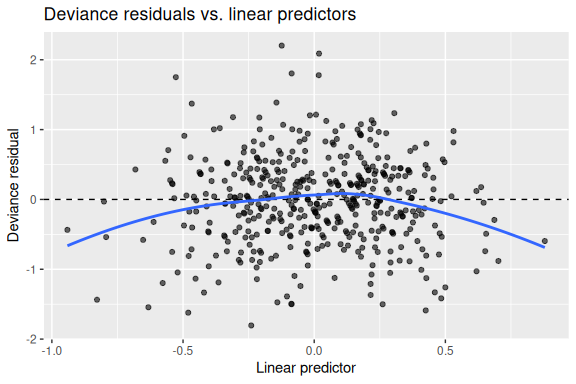

``` r
p2
```

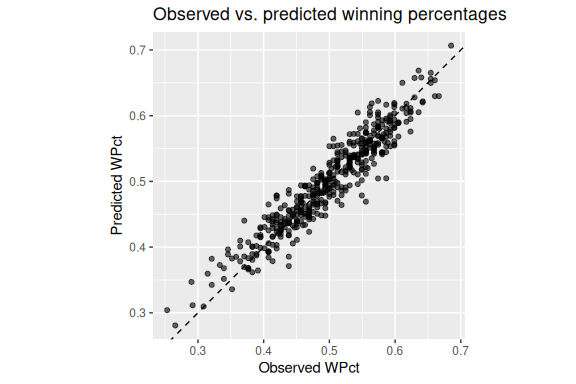

## Python

``` python
deviance_check = pl.DataFrame(
    {
        "residual_deviance": [bill_james_logit.deviance],
        "df": [bill_james_logit.df_resid],
        "deviance_df_ratio": [
            bill_james_logit.deviance / bill_james_logit.df_resid
        ],
        "p_value": [
            chi2.sf(
                bill_james_logit.deviance,
                bill_james_logit.df_resid
            )
        ]
    }
)

diagnostic_dat = logit_model_data.copy()

diagnostic_dat["linear_predictor"] = bill_james_logit.predict(
    X,
    linear=True
)

diagnostic_dat["deviance_residual"] = bill_james_logit.resid_deviance

diagnostic_dat["predicted_WPct"] = bill_james_logit.predict(
    X
)

p1 = (
    ggplot(
        diagnostic_dat,
        aes(
            x="linear_predictor",
            y="deviance_residual"
        )
    )
    + geom_point(alpha=0.6)
    + geom_hline(
        yintercept=0,
        linetype="dashed"
    )
    + geom_smooth(
        se=False
    )
    + labs(
        x="Linear predictor",
        y="Deviance residual",
        title="Deviance residuals vs. linear predictors"
    )
    + theme_minimal()
)

p2 = (
    ggplot(
        diagnostic_dat,
        aes(
            x="WPct",
            y="predicted_WPct"
        )
    )
    + geom_point(alpha=0.6)
    + geom_abline(
        intercept=0,
        slope=1,
        linetype="dashed"
    )
    + coord_equal()
    + labs(
        x="Observed WPct",
        y="Predicted WPct",
        title="Observed vs. predicted winning percentages"
    )
    + theme_minimal()
)

print(deviance_check)
```

    shape: (1, 4)
    ┌───────────────────┬─────┬───────────────────┬─────────┐
    │ residual_deviance ┆ df  ┆ deviance_df_ratio ┆ p_value │
    │ ---               ┆ --- ┆ ---               ┆ ---     │
    │ f64               ┆ i64 ┆ f64               ┆ f64     │
    ╞═══════════════════╪═════╪═══════════════════╪═════════╡
    │ 165.673424        ┆ 419 ┆ 0.395402          ┆ 1.0     │
    └───────────────────┴─────┴───────────────────┴─────────┘

``` python
p1.show()
```

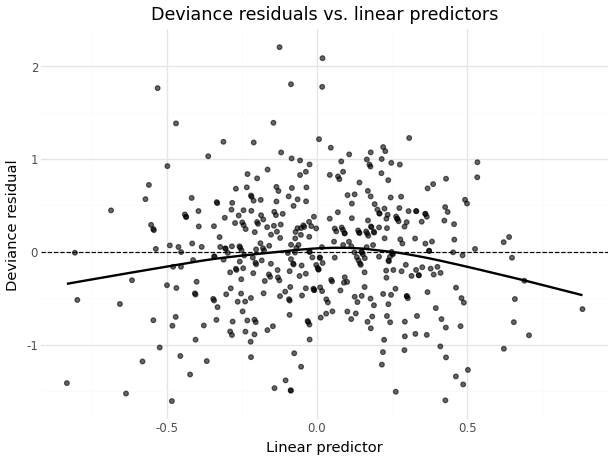

``` python
p2.show()
```

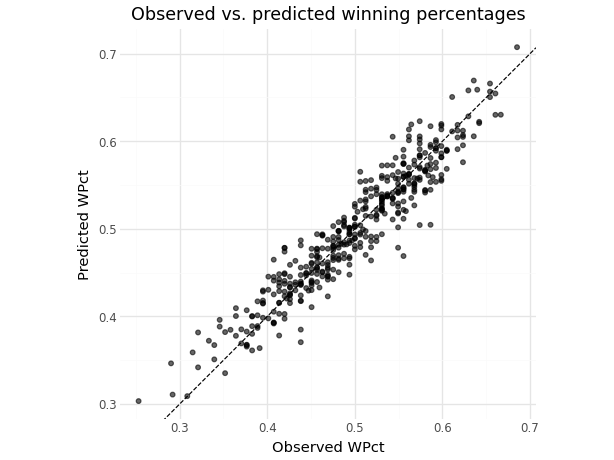

- 잔차 이탈도는 180.0이고 잔차 자유도는 449이므로, 잔차 이탈도와
  자유도의 비율은 약 0.401이다. 잔차 이탈도가 자유도보다 크지 않고
  카이제곱 검정의 p-value도 거의 1이므로, 잔차 이탈도가 지나치게 크다는
  증거는 없다. 따라서 이 진단을 기준으로는 모형 부적합의 증거가 발견되지
  않았다.  
- 이탈도 잔차와 선형 예측변수의 산점도에서 잔차는 전반적으로 0을
  중심으로 분포한다. 평활선이 양 끝에서 다소 아래로 내려가는 약한 곡선
  형태를 보이지만, 뚜렷한 체계적 패턴은 나타나지 않는다.  
- 관측 승률과 예측 승률을 비교한 산점도에서는 대부분의 점이 y=x 직선
  주변에 위치한다. 따라서 득실점 비율을 이용한 로지스틱 회귀모형은 실제
  승률을 전반적으로 잘 설명한다고 판단할 수 있다.

#### 4번

## R

``` r
bill_james_logit_separate <- glm(
  cbind(W, L) ~ log(RA) + log(RS) - 1,
  family = binomial(link = "logit"),
  data = TeamRuns
)

separate_result <- broom::tidy(
  bill_james_logit_separate,
  conf.int = TRUE
)

comparison_extended <- bind_rows(
  nls_result,
  logit_result,
  separate_result %>%
    transmute(
      model = "Logistic regression with separate predictors",
      parameter = term,
      estimate,
      lower = conf.low,
      upper = conf.high
    )
)

comparison_extended
```

    # A tibble: 4 × 5
      model                                        parameter estimate lower upper
      <chr>                                        <chr>        <dbl> <dbl> <dbl>
    1 Nonlinear least squares                      k             1.75  1.70  1.81
    2 Logistic regression                          beta_1        1.75  1.66  1.84
    3 Logistic regression with separate predictors log(RA)      -1.75 -1.84 -1.66
    4 Logistic regression with separate predictors log(RS)       1.75  1.66  1.84

## Python

``` python
TeamRuns = TeamRuns.with_columns(
    [
        pl.col("RA").log().alias("log_RA"),
        pl.col("RS").log().alias("log_RS")
    ]
)

separate_model_data = (
    TeamRuns
    .drop_nulls(
        subset=["W", "L", "log_RA", "log_RS"]
    )
    .to_pandas()
)

y_separate = separate_model_data[["W", "L"]]
X_separate = separate_model_data[["log_RA", "log_RS"]]

bill_james_logit_separate = sm.GLM(
    y_separate,
    X_separate,
    family=sm.families.Binomial(
        link=sm.families.links.Logit()
    )
).fit()

conf_int_separate = bill_james_logit_separate.conf_int()
separate_result = pl.DataFrame(
    {
        "term": bill_james_logit_separate.params.index.to_list(),
        "estimate": bill_james_logit_separate.params.to_numpy(),
        "conf_low": conf_int_separate[0].to_numpy(),
        "conf_high": conf_int_separate[1].to_numpy()
    }
)

comparison_extended = pl.concat(
    [
        nls_result,
        logit_result,
        separate_result.select(
            [
                pl.lit(
                    "Logistic regression with separate predictors"
                ).alias("model"),
                pl.col("term").replace(
                    {
                        "log_RA": "log(RA)",
                        "log_RS": "log(RS)"
                    }
                ).alias("parameter"),
                pl.col("estimate"),
                pl.col("conf_low").alias("lower"),
                pl.col("conf_high").alias("upper")
            ]
        )
    ],
    how="vertical"
)

print(comparison_extended)
```

    shape: (4, 5)
    ┌─────────────────────────────────┬───────────┬───────────┬───────────┬───────────┐
    │ model                           ┆ parameter ┆ estimate  ┆ lower     ┆ upper     │
    │ ---                             ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
    │ str                             ┆ str       ┆ f64       ┆ f64       ┆ f64       │
    ╞═════════════════════════════════╪═══════════╪═══════════╪═══════════╪═══════════╡
    │ Nonlinear least squares         ┆ k         ┆ 1.761041  ┆ 1.701951  ┆ 1.820131  │
    │ Logistic regression             ┆ beta_1    ┆ 1.760815  ┆ 1.66843   ┆ 1.8532    │
    │ Logistic regression with separ… ┆ log(RA)   ┆ -1.761107 ┆ -1.853512 ┆ -1.668703 │
    │ Logistic regression with separ… ┆ log(RS)   ┆ 1.760742  ┆ 1.668356  ┆ 1.853129  │
    └─────────────────────────────────┴───────────┴───────────┴───────────┴───────────┘

- log(RA)와 log(RS)를 각각 설명변수로 포함한 절편 없는 로지스틱
  회귀모형을 적합한 결과, log(RA)의 회귀계수는 약 -1.75, log(RS)의
  회귀계수는 약 1.75로 추정되었다.  
- 두 계수는 절댓값이 거의 같고 부호만 반대이므로, 적합된 모형은
  logit(WPct)≈1.75\*log(RS/RA)로 정리할 수 있다.  
- 이는 2번에서 적합한 logit(WPct)=β_1\*log(RS/RA) 모형과 사실상 동일한
  형태이며, β_1=1.75와도 거의 일치한다.  
- 1번의 비선형 최소제곱 모형에서도 k=1.75로 추정되었으므로, 세 모형 모두
  득점과 실점의 비율이 승률을 설명하는 핵심 변수라는 일관된 결과를
  보여준다.  
- 다만 비선형 최소제곱 모형과 로지스틱 회귀모형은 사용하는 추정 방법이
  다르므로 신뢰구간은 약간 다르게 나타난다.

## 문제 2-2

`WPct`를 반응변수로, `logRS`, `logRA`, `H`, `X2B`, `X3B`, `HR`, `BB`,
`SO`, `CS`, `HBP`, `SF`, `ERA`, `CG`, `SHO`, `IPouts`, `HA`, `HRA`,
`BBA`, `SOA`, `E`, `DP`, `FP`, `SV`를 설명변수로 하는 절편항이 있는
로지스틱 회귀 모형을 적합하고 AIC를 기준으로 하는 단계별(stepwise)
변수선택을 적용하라. 변수선택 후 남은 변수들을 모두 모형에 남길지 일부를
제거할지 다시 판단하라. 최종적으로 선택된 모형을 문제1의 모형과
비교하라.

### 답안

## R

``` r
team_model_data <- Teams %>%
  filter(
    yearID >= 2010,
    yearID <= 2025,
    yearID != 2020
  ) %>%
  rename(RS = R) %>%
  mutate(
    WPct = W / (W + L),
    logRS = log(RS),
    logRA = log(RA)
  ) %>%
  select(
    yearID, teamID, W, L, WPct, RS, RA, logRS, logRA, H, X2B, X3B, HR, BB, SO, CS, HBP, SF, ERA, CG, SHO, IPouts, HA, HRA, BBA, SOA, E, DP, FP, SV
  ) %>%
  drop_na()

team_full <- glm(
  WPct ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + HBP + SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + DP + FP + SV,
  weights = W + L,
  family = binomial(link = "logit"),
  data = team_model_data
)

team_step <- MASS::stepAIC(
  team_full,
  scope = list(
    lower = ~ 1,
    upper = formula(team_full)
  ),
  direction = "both",
  trace = FALSE
)

formula(team_step)
```

    WPct ~ logRS + logRA + CG + SHO + SV

``` r
team_step$anova
```

    Stepwise Model Path 
    Analysis of Deviance Table

    Initial Model:
    WPct ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + HBP + 
        SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + 
        DP + FP + SV

    Final Model:
    WPct ~ logRS + logRA + CG + SHO + SV

           Step Df     Deviance Resid. Df Resid. Dev      AIC
    1                                 426   95.95551 2627.200
    2     - ERA  1 0.0008888482       427   95.95640 2625.201
    3     - X2B  1 0.0035689359       428   95.95997 2623.205
    4      - FP  1 0.0043884065       429   95.96436 2621.209
    5     - HBP  1 0.0416527541       430   96.00601 2619.251
    6       - E  1 0.0441208065       431   96.05013 2617.295
    7     - SOA  1 0.2367976510       432   96.28693 2615.531
    8      - HR  1 0.2290851547       433   96.51602 2613.761
    9     - X3B  1 0.2651878227       434   96.78120 2612.026
    10     - DP  1 0.3380636204       435   97.11927 2610.364
    11     - SF  1 0.4592372700       436   97.57850 2608.823
    12    - BBA  1 0.5518718615       437   98.13038 2607.375
    13     - SO  1 0.8454271527       438   98.97580 2606.220
    14      - H  1 0.5037696550       439   99.47957 2604.724
    15     - BB  1 1.0525805098       440  100.53215 2603.777
    16    - HRA  1 1.2222714313       441  101.75443 2602.999
    17     - HA  1 1.4224111335       442  103.17684 2602.421
    18 - IPouts  1 1.2064813051       443  104.38332 2601.628
    19     - CS  1 1.7360051686       444  106.11932 2601.364

``` r
summary(team_step)
```


    Call:
    glm(formula = WPct ~ logRS + logRA + CG + SHO + SV, family = binomial(link = "logit"), 
        data = team_model_data, weights = W + L)

    Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -2.694019   0.842064  -3.199  0.00138 ** 
    logRS        1.615284   0.071880  22.472  < 2e-16 ***
    logRA       -1.284160   0.101524 -12.649  < 2e-16 ***
    CG           0.004573   0.003014   1.517  0.12926    
    SHO          0.004669   0.002531   1.845  0.06502 .  
    SV           0.011104   0.001324   8.384  < 2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 449  degrees of freedom
    Residual deviance:  106.12  on 444  degrees of freedom
    AIC: 2601.4

    Number of Fisher Scoring iterations: 3

``` r
drop1(team_step, test = "Chisq")
```

    Single term deletions

    Model:
    WPct ~ logRS + logRA + CG + SHO + SV
           Df Deviance    AIC    LRT Pr(>Chi)    
    <none>      106.12 2601.4                    
    logRS   1   616.29 3109.5 510.17  < 2e-16 ***
    logRA   1   266.78 2760.0 160.66  < 2e-16 ***
    CG      1   108.42 2601.7   2.30  0.12919    
    SHO     1   109.52 2602.8   3.40  0.06502 .  
    SV      1   176.50 2669.8  70.38  < 2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

## Python

``` python
team_model_data = (
    Teams
    .filter(
        (pl.col("yearID") >= 2010)
        & (pl.col("yearID") <= 2025)
        & (pl.col("yearID") != 2020)
    )
    .rename({"R": "RS","2B": "X2B", "3B": "X3B"})
    .with_columns(
        [
            (pl.col("W") / (pl.col("W") + pl.col("L"))).alias("WPct"),
            pl.col("RS").log().alias("logRS"),
            pl.col("RA").log().alias("logRA"),
            (pl.col("W") + pl.col("L")).alias("n_games")
        ]
    )
    .select(
        [
            "yearID", "teamID", "W", "L", "WPct", "RS", "RA",
            "logRS", "logRA", "H", "X2B", "X3B", "HR", "BB", "SO",
            "CS", "HBP", "SF", "ERA", "CG", "SHO", "IPouts",
            "HA", "HRA", "BBA", "SOA", "E", "DP", "FP", "SV",
            "n_games"
        ]
    )
    .drop_nulls()
)

team_model_pd = team_model_data.to_pandas()
team_model_pd["weights"] = team_model_pd["W"] + team_model_pd["L"]

all_terms = [
    "logRS", "logRA", "H", "X2B", "X3B", "HR", "BB", "SO",
    "CS", "HBP", "SF", "ERA", "CG", "SHO", "IPouts",
    "HA", "HRA", "BBA", "SOA", "E", "DP", "FP", "SV"
]

def make_X(data, terms):
    if len(terms) == 0:
        X = pd.DataFrame({"const": np.ones(len(data))}, index=data.index)
    else:
        X = data[terms].copy()
        X = sm.add_constant(X, has_constant="add")
    return X


def r_binomial_loglik(fit, data):
    W = data["W"].to_numpy()
    L = data["L"].to_numpy()
    n = W + L

    mu = fit.fittedvalues
    mu = np.clip(mu, 1e-12, 1 - 1e-12)

    loglik = (
        gammaln(n + 1)
        - gammaln(W + 1)
        - gammaln(L + 1)
        + W * np.log(mu)
        + L * np.log(1 - mu)
    ).sum()

    return loglik


def r_like_aic(fit, data):
    loglik = r_binomial_loglik(fit, data)
    k = int(fit.df_model + 1)
    return -2 * loglik + 2 * k


def fit_glm(terms):
    X = make_X(team_model_pd, terms)
    y = team_model_pd[["W", "L"]]

    model = sm.GLM(
        y,
        X,
        family=sm.families.Binomial(link=sm.families.links.Logit())
    )

    fit = model.fit()
    fit.r_like_aic = r_like_aic(fit, team_model_pd)
    fit.terms = terms.copy()

    return fit


def step_aic(start_terms, scope_terms):
    current_terms = start_terms.copy()
    current_fit = fit_glm(current_terms)

    anova_rows = [{
        "Step": "Start",
        "Df Resid.": current_fit.df_resid,
        "Resid. Dev": current_fit.deviance,
        "AIC": current_fit.r_like_aic
    }]

    while True:
        candidates = []

        for term in current_terms:
            new_terms = [x for x in current_terms if x != term]
            new_fit = fit_glm(new_terms)
            candidates.append({
                "action": f"- {term}",
                "terms": new_terms,
                "fit": new_fit,
                "aic": new_fit.r_like_aic
            })

        for term in scope_terms:
            if term not in current_terms:
                new_terms = current_terms + [term]
                new_fit = fit_glm(new_terms)
                candidates.append({
                    "action": f"+ {term}",
                    "terms": new_terms,
                    "fit": new_fit,
                    "aic": new_fit.r_like_aic
                })

        best = min(candidates, key=lambda x: x["aic"])

        if best["aic"] < current_fit.r_like_aic - 1e-7:
            current_terms = best["terms"]
            current_fit = best["fit"]

            anova_rows.append({
                "Step": best["action"],
                "Df Resid.": current_fit.df_resid,
                "Resid. Dev": current_fit.deviance,
                "AIC": current_fit.r_like_aic
            })
        else:
            break

    return current_terms, current_fit, pd.DataFrame(anova_rows)


selected_terms, team_step, team_step_anova = step_aic(all_terms, all_terms)

selected_formula = "WPct ~ " + " + ".join(selected_terms)

def drop1_chisq(final_terms, final_fit):
    rows = []

    for term in final_terms:
        reduced_terms = [x for x in final_terms if x != term]
        reduced_fit = fit_glm(reduced_terms)

        dev_diff = reduced_fit.deviance - final_fit.deviance
        df_diff = int(reduced_fit.df_resid - final_fit.df_resid)
        p_value = chi2.sf(dev_diff, df_diff)

        rows.append({
            "term": term,
            "Df": df_diff,
            "Deviance": reduced_fit.deviance,
            "AIC": reduced_fit.r_like_aic,
            "LRT": dev_diff,
            "Pr(>Chi)": p_value
        })

    return pd.DataFrame(rows)


drop1_result = drop1_chisq(selected_terms, team_step)

print(selected_formula)
```

    WPct ~ logRS + logRA + CG + SHO + SV

``` python
print(team_step_anova)
```

            Step  Df Resid.  Resid. Dev          AIC
    0      Start        396   89.520957  2455.134131
    1      - X2B        397   89.521327  2453.134501
    2       - FP        398   89.529752  2451.142926
    3      - HBP        399   89.545171  2449.158345
    4      - ERA        400   89.594932  2447.208106
    5        - E        401   89.643954  2445.257128
    6      - SOA        402   89.827504  2443.440678
    7       - HR        403   90.024942  2441.638116
    8      - X3B        404   90.162842  2439.776016
    9       - SF        405   90.529191  2438.142365
    10      - DP        406   91.160299  2436.773473
    11     - BBA        407   91.607712  2435.220886
    12      - SO        408   92.262408  2433.875582
    13       - H        409   92.649197  2432.262371
    14      - BB        410   93.564798  2431.177972
    15     - HRA        411   95.027811  2430.640985
    16      - HA        412   96.105723  2429.718896
    17  - IPouts        413   97.119346  2428.732520
    18      - CS        414   98.927724  2428.540898

``` python
print(team_step.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:             ['W', 'L']   No. Observations:                  420
    Model:                            GLM   Df Residuals:                      414
    Model Family:                Binomial   Df Model:                            5
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1208.3
    Date:                Sun, 14 Jun 2026   Deviance:                       98.928
    Time:                        22:17:20   Pearson chi2:                     98.9
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9720
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -2.4801      0.865     -2.866      0.004      -4.176      -0.784
    logRS          1.6169      0.074     21.973      0.000       1.473       1.761
    logRA         -1.3159      0.105    -12.501      0.000      -1.522      -1.110
    CG             0.0044      0.003      1.435      0.151      -0.002       0.011
    SHO            0.0043      0.003      1.653      0.098      -0.001       0.009
    SV             0.0108      0.001      7.936      0.000       0.008       0.013
    ==============================================================================

``` python
print(drop1_result)
```

        term  Df    Deviance          AIC         LRT       Pr(>Chi)
    0  logRS   1  586.872603  2914.485777  487.944880  3.990109e-108
    1  logRA   1  255.876922  2583.490096  156.949198   5.251107e-36
    2     CG   1  100.988422  2428.601596    2.060698   1.511409e-01
    3    SHO   1  101.658677  2429.271851    2.730953   9.842053e-02
    4     SV   1  161.959597  2489.572771   63.031873   2.033886e-15

AIC를 기준으로 단계별 변수선택을 적용한 결과, logRS, logRA, CG, SHO,
SV가 선택되었다.  
그러나 drop1()을 이용하여 각 변수를 하나씩 제외했을 때의 모형 적합도
변화를 확인한 결과, CG의 p-value는 0.129였고 제거 시 AIC는 2601.4에서
2601.7로 0.3만 증가하였다.  
SHO의 p-value도 0.065로 0.05보다 컸으며, 제거 시 AIC는 2602.8로
증가하였지만 기존 모형과의 차이는 1.4로 크지 않았다.

따라서 모형의 간결성을 고려하면 CG와 SHO를 제거한 뒤, logRS, logRA,
SV만을 포함하는 모형을 최종 후보로 둘 수 있다.  
문제 1의 모형은 logit(WPct) = k \* log(RS) - k \* log(RA)와 같이 나타낼
수 있다.  
최종 후보 모형에서도 logRS의 계수는 양수이고 logRA의 계수는 음수이므로
기본적인 관계는 문제 1의 모형과 동일하다.

## 문제 2-3

1.  `W`(승리 횟수)를 반응변수로 하여 문제 2-2의 분석을 실시하되 포아송
    회귀모형을 사용하라. 결과를 문제 2-2의 모형과 비교하라.

2.  `W`를 반응변수로 하여 문제2의 분석을 실시하되 음이항 회귀모형을
    사용하라. 모형 적합 시 오류가 발생하면 이유를 파악해서 보고하라.

### 답안

#### 4번

## R

``` r
team_poisson_full <- glm(
  W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO +
    CS + HBP + SF + ERA + CG + SHO + IPouts + HA +
    HRA + BBA + SOA + E + DP + FP + SV,
  family = poisson,
  data = team_model_data
)

team_poisson_step <- MASS::stepAIC(
  team_poisson_full,
  scope = list(
    lower = ~ 1,
    upper = formula(team_poisson_full)
  ),
  direction = "both",
  trace = FALSE
)

formula(team_poisson_step)
```

    W ~ logRS + ERA + CG + E + SV

``` r
team_poisson_step$anova
```

    Stepwise Model Path 
    Analysis of Deviance Table

    Initial Model:
    W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + HBP + 
        SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + 
        DP + FP + SV

    Final Model:
    W ~ logRS + ERA + CG + E + SV

           Step Df   Deviance Resid. Df Resid. Dev      AIC
    1                               426   55.72979 2903.589
    2      - FP  1 0.00262431       427   55.73241 2901.592
    3     - HBP  1 0.01235945       428   55.74477 2899.604
    4     - X2B  1 0.06924360       429   55.81402 2897.674
    5     - SOA  1 0.12150411       430   55.93552 2895.795
    6     - X3B  1 0.19057320       431   56.12609 2893.986
    7   - logRA  1 0.15180823       432   56.27790 2892.138
    8      - HR  1 0.18089834       433   56.45880 2890.318
    9      - SF  1 0.27606860       434   56.73487 2888.594
    10    - BBA  1 0.32998795       435   57.06486 2886.924
    11     - DP  1 0.32822880       436   57.39308 2885.253
    12     - HA  1 0.61447710       437   58.00756 2883.867
    13    - HRA  1 0.35977568       438   58.36734 2882.227
    14 - IPouts  1 0.34277639       439   58.71011 2880.570
    15     - CS  1 0.41025844       440   59.12037 2878.980
    16     - SO  1 0.42461923       441   59.54499 2877.405
    17      - H  1 0.18209805       442   59.72709 2875.587
    18     - BB  1 0.62629802       443   60.35339 2874.213
    19    - SHO  1 1.94107491       444   62.29446 2874.154

``` r
summary(team_poisson_step)
```


    Call:
    glm(formula = W ~ logRS + ERA + CG + E + SV, family = poisson, 
        data = team_model_data)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -0.3757640  0.3476706  -1.081    0.280    
    logRS        0.7921194  0.0507212  15.617  < 2e-16 ***
    ERA         -0.1534248  0.0134578 -11.400  < 2e-16 ***
    CG           0.0033842  0.0020730   1.633    0.103    
    E           -0.0006008  0.0003532  -1.701    0.089 .  
    SV           0.0056969  0.0009280   6.139 8.29e-10 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for poisson family taken to be 1)

        Null deviance: 865.249  on 449  degrees of freedom
    Residual deviance:  62.294  on 444  degrees of freedom
    AIC: 2874.2

    Number of Fisher Scoring iterations: 3

``` r
drop1(team_poisson_step, test = "Chisq")
```

    Single term deletions

    Model:
    W ~ logRS + ERA + CG + E + SV
           Df Deviance    AIC     LRT  Pr(>Chi)    
    <none>      62.294 2874.2                      
    logRS   1  306.144 3116.0 243.850 < 2.2e-16 ***
    ERA     1  192.694 3002.6 130.399 < 2.2e-16 ***
    CG      1   64.949 2874.8   2.655   0.10325    
    E       1   65.189 2875.1   2.894   0.08889 .  
    SV      1   99.901 2909.8  37.606 8.657e-10 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

## Python

``` python
def make_X(data, terms):
    if len(terms) == 0:
        X = pd.DataFrame({"const": 1.0}, index=data.index)
    else:
        X = data[terms].copy()
        X = sm.add_constant(X, has_constant="add")
    return X


def fit_poisson(terms):
    X = make_X(team_model_pd, terms)
    y = team_model_pd["W"]

    model = sm.GLM(
        y,
        X,
        family=sm.families.Poisson()
    )

    fit = model.fit()
    fit.terms = terms.copy()

    return fit

team_poisson_full = fit_poisson(all_terms)

def step_aic_poisson(start_terms, scope_terms):
    current_terms = start_terms.copy()
    current_fit = fit_poisson(current_terms)

    anova_rows = [{
        "Step": "Start",
        "Df Resid.": current_fit.df_resid,
        "Resid. Dev": current_fit.deviance,
        "AIC": current_fit.aic
    }]

    while True:
        candidates = []

        for term in current_terms:
            new_terms = [x for x in current_terms if x != term]
            new_fit = fit_poisson(new_terms)

            candidates.append({
                "action": f"- {term}",
                "terms": new_terms,
                "fit": new_fit,
                "aic": new_fit.aic
            })

        for term in scope_terms:
            if term not in current_terms:
                new_terms = current_terms + [term]
                new_fit = fit_poisson(new_terms)

                candidates.append({
                    "action": f"+ {term}",
                    "terms": new_terms,
                    "fit": new_fit,
                    "aic": new_fit.aic
                })

        best = min(candidates, key=lambda x: x["aic"])

        if best["aic"] < current_fit.aic - 1e-7:
            current_terms = best["terms"]
            current_fit = best["fit"]

            anova_rows.append({
                "Step": best["action"],
                "Df Resid.": current_fit.df_resid,
                "Resid. Dev": current_fit.deviance,
                "AIC": current_fit.aic
            })
        else:
            break

    return current_terms, current_fit, pd.DataFrame(anova_rows)
poisson_selected_terms, team_poisson_step, team_poisson_step_anova = step_aic_poisson(
    all_terms,
    all_terms
)

poisson_selected_formula = "W ~ " + " + ".join(poisson_selected_terms)

def drop1_poisson_chisq(final_terms, final_fit):
    rows = []

    for term in final_terms:
        reduced_terms = [x for x in final_terms if x != term]
        reduced_fit = fit_poisson(reduced_terms)

        dev_diff = reduced_fit.deviance - final_fit.deviance
        df_diff = int(reduced_fit.df_resid - final_fit.df_resid)
        p_value = chi2.sf(dev_diff, df_diff)

        rows.append({
            "term": term,
            "Df": df_diff,
            "Deviance": reduced_fit.deviance,
            "AIC": reduced_fit.aic,
            "LRT": dev_diff,
            "Pr(>Chi)": p_value
        })

    return pd.DataFrame(rows)


poisson_drop1_result = drop1_poisson_chisq(
    poisson_selected_terms,
    team_poisson_step
)

print(poisson_selected_formula)
```

    W ~ logRS + ERA + CG + E + SV

``` python
print(team_poisson_step_anova)
```

            Step  Df Resid.  Resid. Dev          AIC
    0      Start        396   51.548306  2712.733496
    1       - FP        397   51.548735  2710.733925
    2      - HBP        398   51.553614  2708.738804
    3      - X2B        399   51.593986  2706.779176
    4      - X3B        400   51.681494  2704.866684
    5      - SOA        401   51.791450  2702.976640
    6    - logRA        402   51.958427  2701.143617
    7       - HR        403   52.135391  2699.320580
    8       - SF        404   52.355103  2697.540293
    9      - BBA        405   52.640686  2695.825876
    10      - DP        406   53.172615  2694.357804
    11      - HA        407   53.603559  2692.788749
    12  - IPouts        408   53.835754  2691.020944
    13      - SO        409   54.164824  2689.350014
    14       - H        410   54.418467  2687.603657
    15     - HRA        411   54.749310  2685.934500
    16      - CS        412   55.139407  2684.324597
    17      - BB        413   55.773303  2682.958493
    18     - SHO        414   57.324367  2682.509557

``` python
print(team_poisson_step.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:                      W   No. Observations:                  420
    Model:                            GLM   Df Residuals:                      414
    Model Family:                 Poisson   Df Model:                            5
    Link Function:                    Log   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1335.3
    Date:                Sun, 14 Jun 2026   Deviance:                       57.324
    Time:                        22:17:23   Pearson chi2:                     57.0
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.8344
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -0.3811      0.357     -1.066      0.286      -1.081       0.319
    logRS          0.7954      0.052     15.312      0.000       0.694       0.897
    ERA           -0.1561      0.014    -11.236      0.000      -0.183      -0.129
    CG             0.0033      0.002      1.560      0.119      -0.001       0.007
    E             -0.0006      0.000     -1.582      0.114      -0.001       0.000
    SV             0.0055      0.001      5.827      0.000       0.004       0.007
    ==============================================================================

``` python
print(poisson_drop1_result)
```

        term  Df    Deviance          AIC         LRT      Pr(>Chi)
    0  logRS   1  291.748201  2914.933391  234.423834  6.465723e-53
    1    ERA   1  183.837130  2807.022320  126.512764  2.374695e-29
    2     CG   1   59.749705  2682.934895    2.425339  1.193874e-01
    3      E   1   59.829601  2683.014791    2.505235  1.134686e-01
    4     SV   1   91.194667  2714.379857   33.870300  5.891117e-09

AIC를 기준으로 단계별 변수선택을 적용한 결과, logRS, ERA, CG, E, SV가
선택되었다.  
그러나 drop1() 결과를 확인하면 CG와 E의 p-value는 각각 0.103과 0.089로
0.05보다 크다. 또한 CG 또는 E를 제거했을 때 AIC 증가량도 각각 0.6과
0.9로 크지 않다.

따라서 모형의 간결성을 고려하여 CG와 E를 제거한 W ~ logRS + ERA + SV
모형을 최종 후보로 고려할 수 있다.두 변수를 함께 제거한 모형과 기존
모형을 우도비 검정으로 비교한 뒤, 적합도가 유의하게 나빠지지 않으면
간결한 모형을 최종 모형으로 선택한다.

문제 1의 모형은 득점 수와 실점 수의 비율을 이용하여 승률을 설명한다.
이번 포아송 회귀모형에서도 득점 수가 많을수록 기대 승리 횟수가 증가하고,
ERA가 높을수록 기대 승리 횟수가 감소하는 것으로 나타났다.

#### 2번

## R

``` r
team_nb_full <- MASS::glm.nb(
  W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO +
    CS + HBP + SF + ERA + CG + SHO + IPouts + HA +
    HRA + BBA + SOA + E + DP + FP + SV,
  data = team_model_data
)

summary(team_nb_full)
```


    Call:
    MASS::glm.nb(formula = W ~ logRS + logRA + H + X2B + X3B + HR + 
        BB + SO + CS + HBP + SF + ERA + CG + SHO + IPouts + HA + 
        HRA + BBA + SOA + E + DP + FP + SV, data = team_model_data, 
        init.theta = 10848330.35, link = log)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -1.813e+00  1.515e+01  -0.120    0.905    
    logRS        9.409e-01  1.676e-01   5.614 1.98e-08 ***
    logRA       -1.495e-01  3.186e-01  -0.469    0.639    
    H           -1.191e-04  1.578e-04  -0.755    0.450    
    X2B         -7.447e-05  2.915e-04  -0.255    0.798    
    X3B         -3.169e-04  7.275e-04  -0.436    0.663    
    HR          -1.899e-04  3.154e-04  -0.602    0.547    
    BB          -1.157e-04  1.363e-04  -0.848    0.396    
    SO          -4.715e-05  6.375e-05  -0.740    0.460    
    CS          -4.193e-04  6.124e-04  -0.685    0.494    
    HBP          4.319e-05  3.860e-04   0.112    0.911    
    SF          -4.029e-04  7.996e-04  -0.504    0.614    
    ERA         -6.006e-02  8.039e-02  -0.747    0.455    
    CG           3.113e-03  2.571e-03   1.211    0.226    
    SHO          2.095e-03  1.802e-03   1.163    0.245    
    IPouts       1.968e-04  1.918e-04   1.026    0.305    
    HA          -1.525e-04  1.717e-04  -0.888    0.375    
    HRA         -3.460e-04  3.516e-04  -0.984    0.325    
    BBA         -8.995e-05  1.446e-04  -0.622    0.534    
    SOA          2.439e-05  6.930e-05   0.352    0.725    
    E           -1.460e-04  2.497e-03  -0.058    0.953    
    DP           2.510e-04  3.784e-04   0.663    0.507    
    FP           7.769e-01  1.517e+01   0.051    0.959    
    SV           5.802e-03  9.788e-04   5.928 3.06e-09 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for Negative Binomial(10849178) family taken to be 1)

        Null deviance: 865.243  on 449  degrees of freedom
    Residual deviance:  55.729  on 426  degrees of freedom
    AIC: 2905.6

    Number of Fisher Scoring iterations: 1

                  Theta:  10848330 
              Std. Err.:  108586594 
    Warning while fitting theta: alternation limit reached 

     2 x log-likelihood:  -2855.592 

## Python

``` python
team_nb_full = sm.NegativeBinomial(
    team_model_pd["W"],
    make_X(team_model_pd, all_terms),
    loglike_method="nb2"
).fit()
```

             Current function value: 5.417598
             Iterations: 0
             Function evaluations: 13
             Gradient evaluations: 2

``` python
print(team_nb_full.summary())
```

                         NegativeBinomial Regression Results                      
    ==============================================================================
    Dep. Variable:                      W   No. Observations:                  420
    Model:               NegativeBinomial   Df Residuals:                      396
    Method:                           MLE   Df Model:                           23
    Date:                Sun, 14 Jun 2026   Pseudo R-squ.:                 -0.3725
    Time:                        22:17:24   Log-Likelihood:                -2275.4
    converged:                      False   LL-Null:                       -1657.8
    Covariance Type:            nonrobust   LLR p-value:                     1.000
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -1.2187        nan        nan        nan         nan         nan
    logRS          0.9339        nan        nan        nan         nan         nan
    logRA         -0.1514        nan        nan        nan         nan         nan
    H             -0.0001        nan        nan        nan         nan         nan
    X2B         -5.93e-05        nan        nan        nan         nan         nan
    X3B           -0.0002        nan        nan        nan         nan         nan
    HR            -0.0002        nan        nan        nan         nan         nan
    BB            -0.0001        nan        nan        nan         nan         nan
    SO          -4.33e-05        nan        nan        nan         nan         nan
    CS            -0.0004        nan        nan        nan         nan         nan
    HBP         2.824e-05        nan        nan        nan         nan         nan
    SF            -0.0004        nan        nan        nan         nan         nan
    ERA           -0.0656        nan        nan        nan         nan         nan
    CG             0.0030        nan        nan        nan         nan         nan
    SHO            0.0019        nan        nan        nan         nan         nan
    IPouts         0.0002        nan        nan        nan         nan         nan
    HA            -0.0001        nan        nan        nan         nan         nan
    HRA           -0.0003        nan        nan        nan         nan         nan
    BBA        -8.681e-05        nan        nan        nan         nan         nan
    SOA         2.295e-05        nan        nan        nan         nan         nan
    E             -0.0002        nan        nan        nan         nan         nan
    DP             0.0003        nan        nan        nan         nan         nan
    FP             0.3297        nan        nan        nan         nan         nan
    SV             0.0057        nan        nan        nan         nan         nan
    alpha          1.0513        nan        nan        nan         nan         nan
    ==============================================================================

음이항 회귀모형을 적합한 결과, theta와 theta의 표준오차가 매우 크게
추정되었다. 또한 theta를 추정하는 과정에서 반복 횟수 제한에 도달했다는
경고 메시지가 발생하였다.

음이항분포의 분산은 Var(Y) = mu + mu^2 / theta로 주어진다. theta가 매우
커지면 mu^2 / theta가 0에 가까워지므로, 음이항 회귀모형의 분산은 포아송
회귀모형의 분산인 mu에 가까워진다. 따라서 현재 결과는 자료에서 과산포를
뒷받침하는 증거가 부족하여 theta가 유한한 값으로 안정적으로 추정되지
않았음을 의미한다. 앞에서 적합한 포아송 회귀모형에서도 잔차 이탈도와
잔차 자유도의 비율이 62.294 / 444 = 0.140으로 1보다 훨씬 작게 나타났다.

즉, 현재 자료에서는 과산포가 아니라 과소산포 가능성이 있으며, 과산포를
설명하기 위한 음이항 회귀모형은 적절하지 않은 것으로 판단된다.

따라서 음이항 회귀모형에 대한 단계별 변수선택은 진행하지 않고 포아송
회귀모형의 결과를 사용하는 것이 더 적절하다.

## 문제 2-4

스테로이드 시대인 1994년에서 2005년의 기간과 최근 시대인 2010년에서 2025
기간의 $k$ 계수가 유의하게 변화하는지 파악하기 위해 $i$번째 팀과 연도
$t$에 대해 다음과 같은 식을 생각해 볼 수 있다.
$$  WPct_(i,t)
  =
  \frac{1}{1+(RA_{i,t}/RS_{i,t} )^{k+g I(1994 \leq t \leq 2005)} }$$
이 때 $I(1994 \leq t \leq 2005)$는 괄호안의 조건이 만족되면 1의 값을
가지고 아니면 0의 값을 가지는 지시함수이고, $g$는 스테로이드 시대와 최근
시대의 차이를 나타내는 계수이다. 위의 식에서 $g$가 0과 유의하게 같은지
가설검정을 수행하게 해주는 로지스틱 모형을 적합하고 결과를 해석하라.
(코로나 시즌인 2020년은 제외한다.)

### 답안

## R

``` r
era_data <- Teams %>%
  filter(
    between(yearID, 1994, 2005) |
      between(yearID, 2010, 2025),
    yearID != 2020
  ) %>%
  rename(RS = R) %>%
  mutate(
    WPct = W / (W + L),
    steroid = if_else(
      between(yearID, 1994, 2005),
      1,
      0
    ),
    log_run_ratio = log(RS / RA),
    steroid_log_run_ratio =
      steroid * log_run_ratio
  )

era_fit <- glm(
  WPct ~ log_run_ratio +
    steroid_log_run_ratio - 1,
  weights = W + L,
  family = binomial(link = "logit"),
  data = era_data
)

summary(era_fit)
```


    Call:
    glm(formula = WPct ~ log_run_ratio + steroid_log_run_ratio - 
        1, family = binomial(link = "logit"), data = era_data, weights = W + 
        L)

    Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
    log_run_ratio          1.75320    0.04562  38.433   <2e-16 ***
    steroid_log_run_ratio  0.16157    0.07475   2.161   0.0307 *  
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 2909.19  on 802  degrees of freedom
    Residual deviance:  315.68  on 800  degrees of freedom
    AIC: 4732.7

    Number of Fisher Scoring iterations: 3

``` r
confint(era_fit)
```

                               2.5 %    97.5 %
    log_run_ratio         1.66387948 1.8426980
    steroid_log_run_ratio 0.01509905 0.3081213

## Python

``` python
era_data = (
    Teams
    .filter(
        (
            ((pl.col("yearID") >= 1994) & (pl.col("yearID") <= 2005))
            |
            ((pl.col("yearID") >= 2010) & (pl.col("yearID") <= 2025))
        )
        &
        (pl.col("yearID") != 2020)
    )
    .rename({"R": "RS"})
    .with_columns(
        [
            (pl.col("W") / (pl.col("W") + pl.col("L"))).alias("WPct"),
            (
                pl.when((pl.col("yearID") >= 1994) & (pl.col("yearID") <= 2005))
                .then(1)
                .otherwise(0)
            ).alias("steroid"),
            (pl.col("RS") / pl.col("RA")).log().alias("log_run_ratio")
        ]
    )
    .with_columns(
        (pl.col("steroid") * pl.col("log_run_ratio")).alias("steroid_log_run_ratio")
    )
)

era_pd = era_data.to_pandas()

X_era = era_pd[["log_run_ratio", "steroid_log_run_ratio"]]
y_era = era_pd[["W", "L"]]

era_fit = sm.GLM(
    y_era,
    X_era,
    family=sm.families.Binomial()
).fit()

print(era_fit.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:             ['W', 'L']   No. Observations:                  772
    Model:                            GLM   Df Residuals:                      770
    Model Family:                Binomial   Df Model:                            1
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -2274.3
    Date:                Sun, 14 Jun 2026   Deviance:                       301.09
    Time:                        22:17:24   Pearson chi2:                     301.
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9612
    Covariance Type:            nonrobust                                         
    =========================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
    -----------------------------------------------------------------------------------------
    log_run_ratio             1.7608      0.047     37.356      0.000       1.668       1.853
    steroid_log_run_ratio     0.1540      0.076      2.034      0.042       0.006       0.302
    =========================================================================================

``` python
print(era_fit.conf_int())
```

                                 0       1
    log_run_ratio          1.66843  1.8532
    steroid_log_run_ratio  0.00561  0.3023

최근 시대의 k는 약 1.753으로 추정되었고, 스테로이드 시대와 최근 시대의
차이를 나타내는 g는 약 0.162로 추정되었다. 따라서 스테로이드 시대의 k는
1.753 + 0.162 = 1.915로 추정된다.

g에 대한 p-value는 0.0307이고 95% 신뢰구간은 (0.015, 0.308)로 0을
포함하지 않는다. 따라서 유의수준 5%에서 H0: g = 0을 기각한다. 즉,
스테로이드 시대와 최근 시대의 k 계수는 통계적으로 유의하게 다르다고 볼
수 있다.

스테로이드 시대의 k가 더 크게 추정되었으므로 스테로이드 시대에는 득실점
비율이 승률에 미치는 영향이 최근 시대보다 더 강하게 나타났다고 해석할 수
있다.

# 3부 데이터 분석 기술

숙제 2에서는 제출용 GitHub 저장소에 작업한 Quarto markdown 소스
파일(`hw02.qmd`)을 올리면 GitHub에서 자동으로 HTML 파일 및 주피터 노트북
파일(`.ipynb`)을 만들고 이것을 [GitHub
Pages](https://docs.github.com/en/pages/quickstart)에서 웹페이지로
보이도록 설정하였다. 여기서는 숙제 3 제출용 GibHub 저장소에 작업한
Quarto markdown 소스 파일(`hw03.qmd`)을 올리면 숙제 2에서의 작업
프로세스에 더해 자동 생성된 `.ipynb` 파일을 컨테이너화하여, GitHub에서
자동 생성된 컨테이너 이미지를 Binder 서비스를 이용하여 온라인에서 주피터
노트북 파일을 사용할 수 있도록 한다.

## 문제 3-1. Dockerfile 설정

로컬 저장소 최상위 디렉토리에 아래와 같은 `Dockerfile` 파일을 추가한다.

In [ ]:
# 1. 기반 이미지 설정
FROM rocker/tidyverse:4.4.0

# 2. 시스템 의존성 설치 (ImageMagick 포함)
USER root
RUN apt-get update && apt-get install -y \
    wget \
    git \
    imagemagick \
    libmagick++-dev \
    && rm -rf /var/lib/apt/lists/*

# 3. Miniconda 설치
ENV CONDA_DIR /opt/conda
RUN wget --quiet https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda.sh && \
    /bin/bash ~/miniconda.sh -b -p /opt/conda && \
    rm ~/miniconda.sh

# 4. Conda 경로 설정 및 환경 생성
ENV PATH=$CONDA_DIR/bin:$PATH
RUN conda create -n r-reticulate python=3.10 -y && \
    conda install -n r-reticulate -c conda-forge numpy pandas matplotlib -y
# 추가로 필요한 패키지 설치

# 5. R 패키지 설치 (reticulate 및 필수 패키지)
RUN R -e "install.packages(c('reticulate', 'remotes', 'IRkernel'))" && \
    R -e "IRkernel::installspec(user = FALSE)"
# 추가로 필요한 패키지 설치

# 6. reticulate가 사용할 Python 경로 고정 (환경 변수)
ENV RETICULATE_PYTHON=/opt/conda/envs/r-reticulate/bin/python

# 7. Binder용 jovyan 유저 생성
ENV NB_USER=jovyan
ENV NB_UID=1000
RUN usermod -l ${NB_USER} rstudio && \
    usermod -d /home/${NB_USER} -m ${NB_USER} && \
    chown -R ${NB_USER} /opt/conda /home/${NB_USER}
    
# 8. 노트북 파일 복사
COPY _site/hw03.ipynb /home/${NB_USER}/hw03.ipynb
RUN chown ${NB_USER}:users /home/${NB_USER}/hw03.ipynb

USER ${NB_USER}
WORKDIR /home/${NB_USER}

# Binder가 기대하는 포트
EXPOSE 8888


### 답안

## 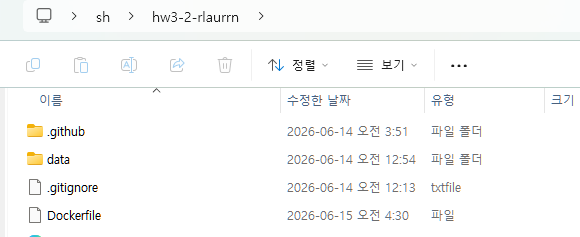

## 문제 3-2. GitHub Actions 워크플로우 수정

숙제 2에서 만들었던 `publish.yml`을 수정하여 기존의 배포 단계 끝에
Docker 컨테이너 이미지를 빌드하고 Github Container Registry (GHCR)에
푸시하는 단계를 추가한다.

In [ ]:
# ... (기존 Quarto Render 단계 이후)

      - name: Log in to GitHub Container Registry
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}

      - name: Build and push Docker image
        uses: docker/build-push-action@v5
        with:
          context: .
          push: true
          tags: ghcr.io/${{ github.repository_owner }}/my-r-env:latest

### 답안

## 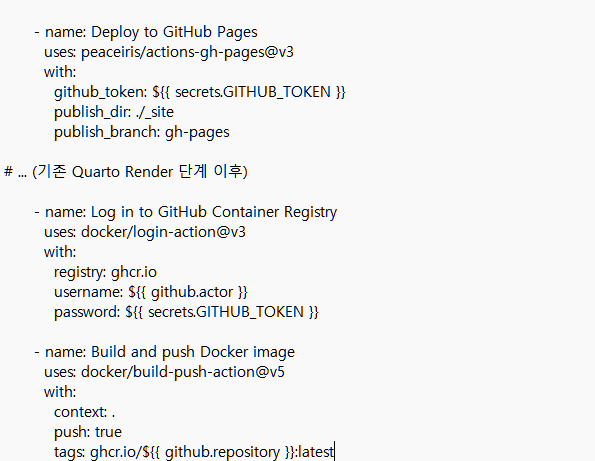

## 문제 3-3. GitHub Pages에 Binder 링크 추가

GitHub Page를 사용하여 저장소를 웹페이지로 활용하는 부분은 숙제 2에서와
같다.

웹페이지에서 노트북을 내려받는 대신 [Binder](mybinder.org) 서비스를
이용하여 온라인으로 노트북을 실행할 수 있도록 위해 `README.md` 파일을
로컬 저장소 최상위 디렉토리에 다음과 같이 만들자.

In [ ]:
# 숙제 3

이름: [아무개]
학번: [나의 학번]

이 숙제의 상세 분석 결과는 아래 링크에서 확인하실 수 있습니다.

* [분석 리포트 (HTML)](./hw03.html) 
* [주피터 노트북 (ipynb)](https://mybinder.org/v2/gh/<유저명>/snu-stat/<repo명>/gh-pages?filepath=hw03.ipynb

여기서 `<유저명>`은 제출자의 GitHub 유저 아이디이며, `<repo명>`은 hw3-로
시작하는 제출자의 repository 이름이다.

작업을 GitHub 원격 저장소로 push한 후 숙제 2 문제 3-3의 3, 4번 과정을
반복하라.

### 답안

## 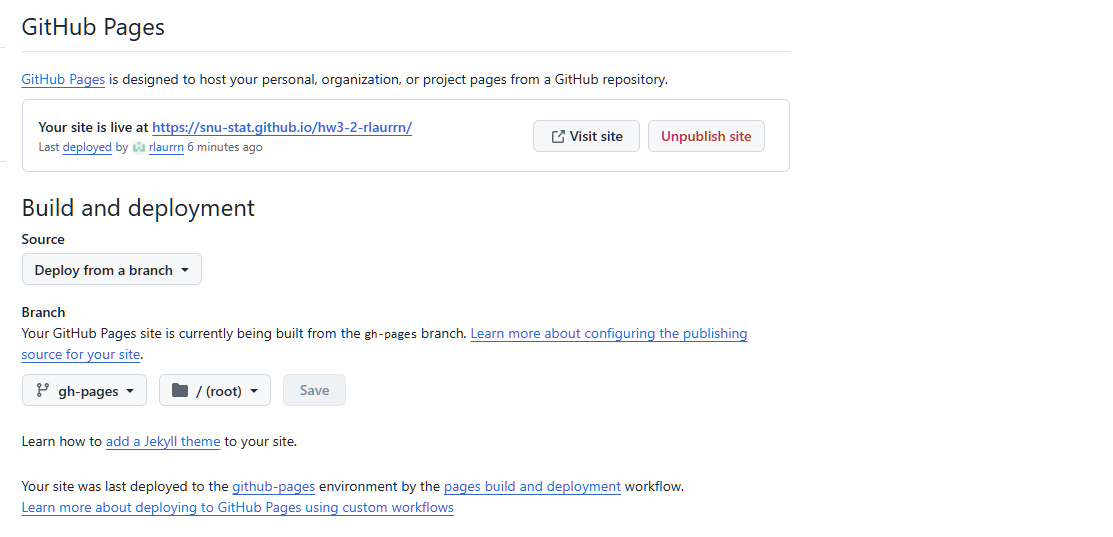